# **Kernel Methods Assignment**
ECE 645 – Machine Learning  
University of Hawaiʻi  

Group Members:
- Christian Falcon
- Nathaniel Anleitner
- Peipei Xu
- Mrinmoy Modak
- Name 5
- Name 6

---

This notebook contains the code and theoretical explanations for the Kernel Methods assignment.

Table of Contents:

1. Distance from a point to a plane (Proof)
2. Cross-validated generalization error estimate for SVC
3. Topic classification using Support Vector Classifiers
4. Credit risk prediction using kernel SVMs

### Imports

In [32]:
import sklearn as skl
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
from IPython.display import display
from sklearn import datasets
from sklearn.model_selection import train_test_split as tts

---
# **Problem 1:**
## **Distance of a Point to a Plane**

Show that the distance of a point from a plane is

$$
\frac{\mathbf{w^T} \mathbf{x} - b}{\|\mathbf{w}\|}
$$

where, as usual, $\|\mathbf{w}\|$ is the length of the vector $\mathbf{w}$.

This needs to be written as a **proper proof**.

## Proof

Define a plane by the equation:

$$
\mathbf{w}^T \mathbf{x} - b = 0
$$

where $\mathbf{w}$ is a vector normal to the plane.

1. **Choose a point on the plane.**  
   Let $\mathbf{x}$ be an arbitrary point in $\mathbb{R}^n$. Choose a point $\mathbf{x_0}$ that lies on the plane, so that

   $$
   \mathbf{w}^T \mathbf{x_0} = b.
   $$

2. **Define the displacement vector.**  
   Define the vector from the point on the plane $\mathbf{x_0}$ to the point $\mathbf{x}$ as

   $$
   \mathbf{e} = \mathbf{x} - \mathbf{x_0}.
   $$

3. **Use orthogonality of the normal vector.**  
   Since $\mathbf{w}$ is perpendicular to the plane, the shortest distance from $\mathbf{x}$ to the plane occurs along the direction of $\mathbf{w}$. Thus the distance is the magnitude of the component of $\mathbf{e}$ in the direction of $\mathbf{w}$.

4. **Normalize the normal vector  $\mathbf{w}$**  
   Let the unit vector in the direction of $\mathbf{w}$ be

   $$
   \hat{\mathbf{w}} = \frac{\mathbf{w}}{\|\mathbf{w}\|}.
   $$

5. **Compute the projection.**  
   The distance from $\mathbf{w}$ to the plane is the magnitude of the projection of $\mathbf{e}$ onto $\hat{\mathbf{w}}$:

   $$
   d = |\hat{\mathbf{w}}^T \mathbf{e}|.
   $$

6. **Substitute the definitions.**  
   Substituting $\mathbf{e} = \mathbf{x} - \mathbf{x_0}$ and $\hat{\mathbf{w}} = \frac{\mathbf{w}}{\|\mathbf{w}\|}$,

   $$
   d = \left|\frac{\mathbf{w}^T (\mathbf{x} - \mathbf{x_0})}{\|\mathbf{w}\|}\right|.
   $$

7. **Distribute the dot product.**

   $$
   d = \frac{|\mathbf{w}^T \mathbf{x} - \mathbf{w}^T \mathbf{x_0}|}{\|\mathbf{w}\|}.
   $$

8. **Use the plane condition.**  
   Since $\mathbf{x_0}$ lies on the plane, $\mathbf{w}^T \mathbf{x_0} = b$, Substituting for b, we get

   $$
   d = \frac{|\mathbf{w}^T \mathbf{x} - b|}{\|\mathbf{w}\|}.
   $$

Therefore, the distance from any point $\mathbf{x}$ to the plane $\mathbf{w}^T \mathbf{x} - b = 0$ is

$$
\boxed{d = \frac{|\mathbf{w}^T \mathbf{x} - b|}{\|\mathbf{w}\|}}
$$

---

# **Problem 2:**
## **Cross-validated Estimate of Generalization Error**

Consider training data

$$
(x_1, y_1), \dots, (x_n, y_n)
$$

Suppose the SVC produces k support vectors.

We want to show that the **leave-one-out cross-validation estimate of generalization error** is

$$
\frac{k}{n}
$$

## Proof

---
Define the *leave-one-out error* of an SVC trained on a dataset S as:

$$ LOO(S) = \frac{1}{n} \sum_{i=1}^{n} \mathbb{I} \{h_{S \backslash \{(x_i, y_i)\}}(x_i)\neq y_i\}$$

for a dataset of size *n*, *h* is the hypothesis of the SVC when trained on dataset S.

$$
\begin{aligned}
\mathbb{E}_{S \sim D^{n+1}}[LOO(S)] &= \frac{1}{n + 1} \sum_{i=1}^{n+1} \mathbb{E}_{S \sim D^{n+1}}[\mathbb{I}\{h_{S \backslash \{(x_i, y_i)\}}(x_i) \neq y_i\}] \\
&= \mathbb{E}_{S \sim D^{n+1}}[\mathbb{I}\{h_{S \backslash \{(x_1, y_1)\}}(x_1) \neq y_1\}] \\
&= \mathbb{E}_{(x,y) \sim D, S \sim D^n}[\mathbb{I}\{h_S(x) \neq y\}] \\
\end{aligned}
$$

Which comes from the assumption that the data in $S$ are distributed in an i.i.d. manner

$$
\begin{aligned}
&= \mathbb{E}_{S \sim D^n}[\mathrm{err}(h_S)]
\end{aligned}
$$

Now, we should consider the SVC trained on a dataset similar in all ways, except that it is missing an (x, y) pair. If that x was not one of the support vectors the hypothesis made by the SVC, then the decision plane would not change, and additionally, x would be classified correctly by the SVC. There is a chance that leaving a support vector would misclassify the left-out point. So,
$$LOO(S) \leq \frac{k}{n}$$

Additionally,
$$\mathbb{E}_{S\sim D^{n}}[\text{err}(h_{S})] = \mathbb{E}_{S\sim D^{n+1}}[LOO(S)] \leq \mathbb{E}_{S \sim D^{n+1}}[\frac{k}{n}]$$

# **Problem 3:**
## **Topic Classification with Support Vector Classifiers**

In this problem we use the 20 Newsgroups dataset from `scikit-learn` to build topic classifiers using Support Vector Classifiers (SVC) with different kernels.

The dataset contains text documents grouped into 20 different discussion topics. The goal is to train a classifier that can correctly predict the topic of each document.

We will compare the performance of SVC models using the following kernels:

- **Linear Kernel**
- **Radial Basis Function (RBF) Kernel**
- **Matern Kernel**

For each model, hyperparameters will be optimized using `GridSearchCV`.



## Tasks

1. Compare performance on a held-out validation set across the three kernels and discuss why the results look the way they do.

2. For each kernel, identify:
   - **Support vectors**
   - **Misclassified training samples**
   - **Vectors lying directly on the margin**

3. Compare the validation performance with the generalization error estimate from Problem 2.

4. Investigate how to assign probabilities to class labels and justify why this approach is reasonable.


In [ ]:
news_data_train = datasets.fetch_20newsgroups_vectorized(subset='train')
news_data_test = datasets.fetch_20newsgroups_vectorized(subset='test')

In [ ]:
X_train, X_val, y_train, y_val = tts(news_data_train.data,
                                     news_data_train.target,
                                     test_size=0.2,
                                     random_state=42
                                     )    

In [ ]:
"""
For this, I want to make a class that trains Support Vector Classifiers for
one-versus-rest classfication tasks. For each of these, I will need to use
gridsearchcv to optimize the hyperparameters.
"""
from sklearn.svm import SVC
from sklearn.gaussian_process.kernels import Matern
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from typing import Dict, List

def get_predefined_split(X_train, y_train, val_length):
  test_fold = np.concatenate([
      -1 * np.ones(X_train.shape[0] - val_length),
      np.zeros(val_length)
  ])

  return PredefinedSplit(test_fold)



class OVR_SVC:

  def __init__(
      self,
      num_classes: int,
      parameters: Dict[str, List[float]],
      split,
      margin_eps: float = 1e-3
      ):
    self.svc_dict = {
        i: GridSearchCV(
            SVC(),
            param_grid=parameters,
            cv=split,
            n_jobs=-1
            ) for i in range(num_classes)
    }
    self.num_classes = num_classes
    self.scores = {}
    self.margin_eps = margin_eps

  # This function will convert labels in the desired class to 1 and -1 for every other class label
  def get_binary_labels(self, y, class_id):
    ovr_y = []
    for j in range(len(y)):
      if y[j] == class_id:
        ovr_y.append(1)
      else:
        ovr_y.append(-1)
    return ovr_y

  # This function will train each class for all classes passed to the function
  def fit(self, X, y, classes, logging=True):
    for class_id in classes:
      ovr_y = self.get_binary_labels(y, class_id)
      self.svc_dict[class_id].fit(X, ovr_y)
      if logging == True:
        print(f"Finished fitting for class {class_id}")
    print("Finished fitting for all classes")

  # This function will calculate the accuracy of each trained classifier
  def validate(self, X, y, classes, logging=True):
    for class_id in classes:
      ovr_y = self.get_binary_labels(y, class_id)

      score = self.svc_dict[class_id].score(X, ovr_y)
      self.scores[class_id] = score
      if logging == True:
        print(f"Class {class_id} score: {score:.4f}")
    print("Finished Validating")

  # This function will predict labels for a given class, using the 
  def get_y_pred(self, X, class_id):
    y_pred = self.svc_dict[class_id].predict(X)
    return y_pred

  # This function will print a classification report a classifier that is passed to the function
  def print_classification_report(self, y_true, y_pred, class_id=None, **kwargs):
    target_names = None
    if class_id is not None:
      target_names = [f"not class {class_id}", f"class {class_id}"]
    report = classification_report(
        y_true,
        y_pred,
        labels=[-1, 1],
        target_names=target_names,
        **kwargs
    )
    print(report)
    return report

  # this function will calculate the confusuion matrix for each specified classifier id. it will return the confusion matrix
  # and display the confusion matrix
  def display_confusion_matrix(self, y_true, y_pred, class_id=None, normalize='true', cmap='Blues', ax=None, show=True):
    c_matrix = confusion_matrix(y_true, y_pred, labels=[-1, 1], normalize=normalize)
    display_labels = ["not class", "class"]
    if class_id is not None:
      display_labels = [f"not class {class_id}", f"class {class_id}"]
    disp = ConfusionMatrixDisplay(
        confusion_matrix=c_matrix,
        display_labels=display_labels
    )
    value_format = '.2f' if normalize is not None else 'd'
    if ax is None:
      fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap=cmap, values_format=value_format, colorbar=False)
    title = "Confusion Matrix"
    if class_id is not None:
      title = f"Confusion Matrix for Class {class_id}"
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    if show:
      plt.tight_layout()
      plt.show()
    return c_matrix
  
  # This function will use the .support_ function to get the total number of support vectors
  def get_support_vectors(self, X, class_id):
    model = self.svc_dict[class_id].best_estimator_
    support_idx = model.support_
    support_vectors = X[support_idx]

    return support_idx, support_vectors
  
  # This will use the decision function m_i = y_i * (wTx_i + b) for a given class
  def get_margin_score(self, X, y, class_id):
    model = self.svc_dict[class_id].best_estimator_
    ovr_y = self.get_binary_labels(y, class_id)

    scores = model.decision_function(X)
    # Convert the binary class list into an array
    m = np.asarray(ovr_y) * scores

    return m
  
    # misclassified vectors: indices where m < 0
    # boundary vectors: indices where m = 0
    # inside margin vectors: indices where 0 < m < 1
    # on margin vectors: indices where m  = 1
    # outside margin vectors: indices where m > 1
  
  # This function will get the indices and vectors that are misclassified or m < 0 for a given class
  def get_misclassified_samples(self, X, y, class_id, eps=None):
    if eps is None:
      eps = self.margin_eps
    ovr_y = self.get_binary_labels(y, class_id)
    m = self.get_margin_score(X, y, class_id)

    misclassified_idx = [idx for idx, m_score in enumerate(m) if m_score < -eps]

    misclassified_X = X[misclassified_idx]    
    misclassified_y = [ovr_y[idx] for idx in misclassified_idx]

    return misclassified_idx, misclassified_X, misclassified_y
  
  # This function will get the indices and vectors that are on the boundaries or m = 0 for a given class
  def get_on_boundary_samples(self, X, y, class_id, eps=None):
    if eps is None:
      eps = self.margin_eps
    ovr_y = self.get_binary_labels(y, class_id)
    m = self.get_margin_score(X, y, class_id)

    on_boundary_idx = [idx for idx, m_score in enumerate(m) if abs(m_score) <= eps]
    on_boundary_X = X[on_boundary_idx]
    on_boundary_y = [ovr_y[idx] for idx in on_boundary_idx]

    return on_boundary_idx, on_boundary_X, on_boundary_y

  # This function will get the indices and vectors that are inside the margin or 0 < m < 1 for a given class
  def get_inside_margin_samples(self, X, y, class_id, eps=None):
    if eps is None:
      eps = self.margin_eps
    ovr_y = self.get_binary_labels(y, class_id)
    m = self.get_margin_score(X, y, class_id)

    inside_margin_idx = [idx for idx, m_score in enumerate(m) if eps < m_score < 1-eps]
    inside_margin_X = X[inside_margin_idx]
    inside_margin_y = [ovr_y[idx] for idx in inside_margin_idx]

    return inside_margin_idx, inside_margin_X, inside_margin_y
  
  # This function will get the indices and vectors that are on the margin or m = 1 for a given class
  def get_on_margin_samples(self, X, y, class_id, eps=None):
    if eps is None:
      eps = self.margin_eps
    ovr_y = self.get_binary_labels(y, class_id)
    m = self.get_margin_score(X, y, class_id)
    on_margin_idx = [idx for idx, m_score in enumerate(m) if abs(m_score-1) <= eps]
    on_margin_X = X[on_margin_idx]
    on_margin_y = [ovr_y[idx] for idx in on_margin_idx]

    return on_margin_idx, on_margin_X, on_margin_y
  
  # This function will get the indices and vectors that are correctly classified or m > 1 for a given class
  def get_outside_boundary_samples(self, X, y, class_id, eps=None):
    if eps is None:
      eps = self.margin_eps
    ovr_y = self.get_binary_labels(y, class_id)
    m = self.get_margin_score(X, y, class_id)
    outisde_boundary_idx = [idx for idx, m_score in enumerate(m) if m_score > 1 + eps]
    outisde_boundary_X = X[outisde_boundary_idx]
    outisde_boundary_y = [ovr_y[idx] for idx in outisde_boundary_idx]

    return outisde_boundary_idx, outisde_boundary_X, outisde_boundary_y

  # This function 
  def summarize_margin_samples(self, X, y, class_id, eps=None):
    if eps is None:
      eps = self.margin_eps

    model = self.svc_dict[class_id].best_estimator_
    ovr_y = np.asarray(self.get_binary_labels(y, class_id))
    m = self.get_margin_score(X, y, class_id)

    indices_dict = {
      'support': model.support_,
      # use numpy where function since m is a numpy array
      'misclassified': np.where(m < -eps)[0],
      'on_boundary': np.where(np.abs(m) <= eps)[0],
      'inside_margin': np.where((m > eps) & (m < 1 - eps))[0],
      'on_margin': np.where(np.abs(m - 1) <= eps)[0],
      'outside_margin': np.where(m > 1 + eps)[0]
    }

    indices_dict['support_ratio'] = len(indices_dict['support']) / X.shape[0]

    index_keys = [
      'support',
      'misclassified',
      'on_boundary',
      'inside_margin',
      'on_margin',
      'outside_margin'
    ]

    X_dict = {name: X[indices_dict[name]] for name in index_keys}
    y_dict = {name: ovr_y[indices_dict[name]] for name in index_keys}

    return indices_dict, X_dict, y_dict

  def get_score(self, class_id):
    return self.scores.get(class_id)
  
  def get_all_scores(self):
    return self.scores


In [31]:
def get_elapsed_time(now):
    time_elapsed = time.time() - now
    if time_elapsed < 60:
        print(f"Time elapsed: {time_elapsed:.2f} seconds")
        return None
    print(f"Time elapsed: {time_elapsed/60:.4f} minutes")    

def margin_summary_dict_to_df(summary_dict, display_on=True):
    rows = []

    for class_id, summary in summary_dict.items():
        row = {'class_id': class_id}
        for key, values in summary.items():
            if isinstance(values, (list, tuple, set, np.ndarray, pd.Series)):
                row[key] = len(values)
            else:
                row[key] = values
        rows.append(row)

    df = pd.DataFrame(rows).sort_values('class_id').reset_index(drop=True)
    if display_on == True:
        display(df)
    return df

In [12]:
val_length = int(X_train.shape[0]*0.1)

linear_params = {
    'kernel': ['linear'],
    'C': [0.5, 1, 10]
}

rbf_params = {
    'kernel': ['rbf'],
    'gamma': [0.5, 1, 10],
    'C': [0.5, 1, 10]
}

strat_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Linear Kernel

In [ ]:
now = time.time()
linear_SVC = OVR_SVC(20, linear_params, strat_cv)
linear_SVC.fit(X_train, y_train, range(20), logging=False)
linear_SVC.validate(X_val, y_val, range(20), logging=False)
get_elapsed_time(now)

Finished fitting for all classes
Finished Validating
Time elapsed: 1229.88 seconds


In [29]:
now = time.time()
linear_margin_summaries = {
    class_id: linear_SVC.summarize_margin_samples(X_train, y_train, class_id)[0]
    for class_id in range(20)
}
linear_margin_summary_df = margin_summary_dict_to_df(linear_margin_summaries)
get_elapsed_time(now)

,class_id,support,misclassified,on_boundary,inside_margin,on_margin,outside_margin,support_ratio
0,0,1013,1,0,23,999,8028,0.111921
1,1,1496,3,0,10,1489,7549,0.165286
2,2,1276,2,0,11,1269,7769,0.140979
3,3,1538,2,0,22,1520,7507,0.169926
4,4,1401,1,0,6,1407,7637,0.154790
5,5,1337,0,0,5,1337,7709,0.147718
6,6,1179,4,0,10,1169,7868,0.130262
7,7,1416,2,0,15,1409,7625,0.156447
8,8,1318,1,0,2,1321,7727,0.145619
9,9,1313,0,0,4,1314,7733,0.145067


Time elapsed: 282.2507 seconds


<Figure size 1400x600 with 0 Axes>

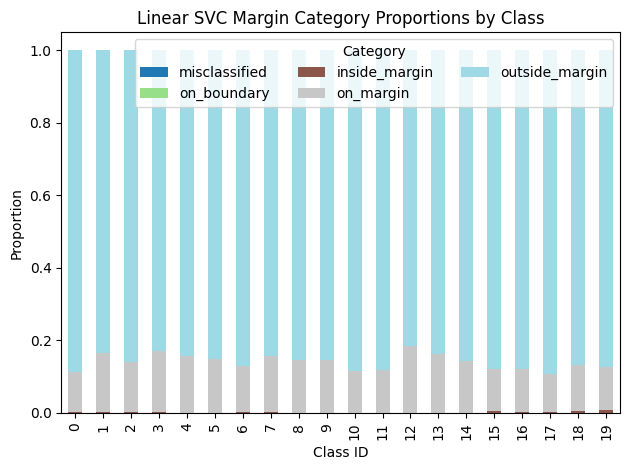

In [30]:
margin_cols = [
    "misclassified",
    "on_boundary",
    "inside_margin",
    "on_margin",
    "outside_margin",
]
margin_frac = (
    linear_margin_summary_df.set_index("class_id")[margin_cols]
    .div(linear_margin_summary_df[margin_cols].sum(axis=1), axis=0)
)

plt.figure(figsize=(14, 6))
margin_frac.plot(kind="bar", stacked=True, colormap="tab20")
plt.title("Linear SVC Margin Category Proportions by Class")
plt.xlabel("Class ID")
plt.ylabel("Proportion")
plt.legend(title="Category", ncol=3)
plt.tight_layout()
plt.show()


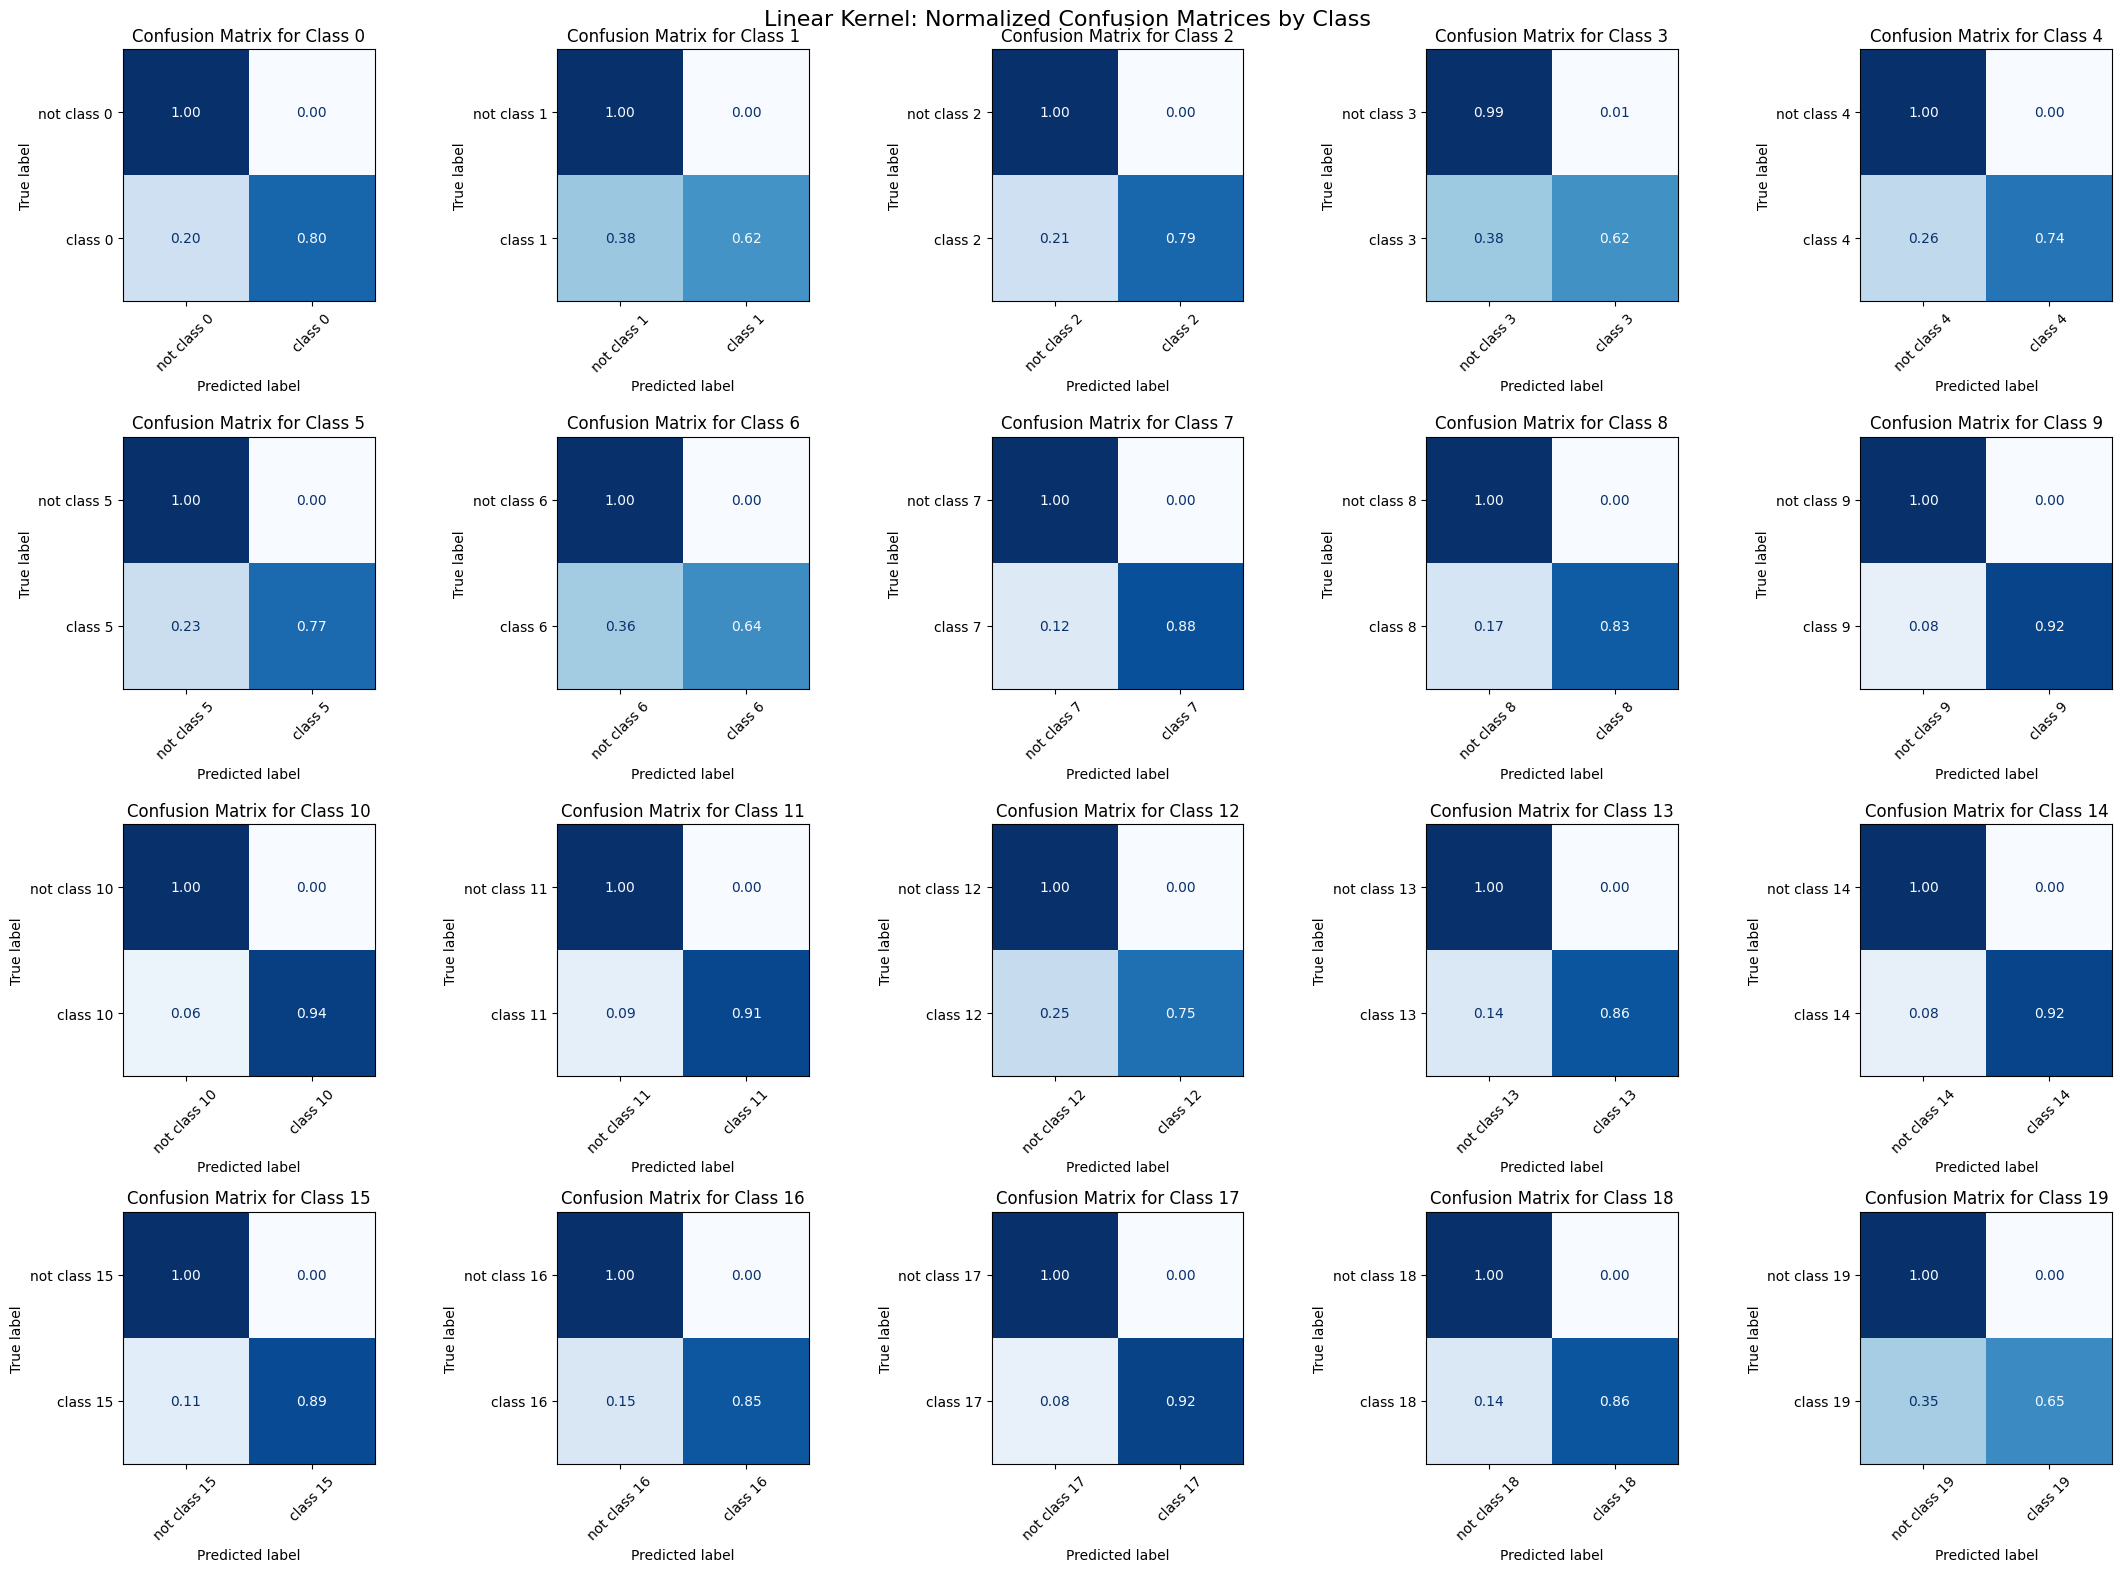

In [ ]:
svc_model = linear_SVC
kernel_name = 'Linear'

all_confusion_matrices = {}
fig, axes = plt.subplots(4, 5, figsize=(22, 16))

for class_id, ax in zip(range(20), axes.flat):
    y_true = svc_model.get_binary_labels(y_val, class_id)
    y_pred = svc_model.get_y_pred(X_val, class_id)
    c_matrix = svc_model.display_confusion_matrix(
        y_true,
        y_pred,
        class_id=class_id,
        normalize='true',
        ax=ax,
        show=False
    )
    all_confusion_matrices[class_id] = c_matrix

fig.suptitle(f'{kernel_name} Kernel: Normalized Confusion Matrices by Class', fontsize=16)
plt.tight_layout()
plt.show()

### RBF Kernel

In [18]:
now = time.time()
rbf_SVC = OVR_SVC(20, rbf_params, strat_cv)
rbf_SVC.fit(X_train, y_train, range(20), logging=False)
rbf_SVC.validate(X_val, y_val, range(20), logging=False)


KeyboardInterrupt: 

              precision    recall  f1-score   support

 not class 0     0.9918    0.9991    0.9954      2170
     class 0     0.9740    0.8065    0.8824        93

    accuracy                         0.9912      2263
   macro avg     0.9829    0.9028    0.9389      2263
weighted avg     0.9910    0.9912    0.9908      2263



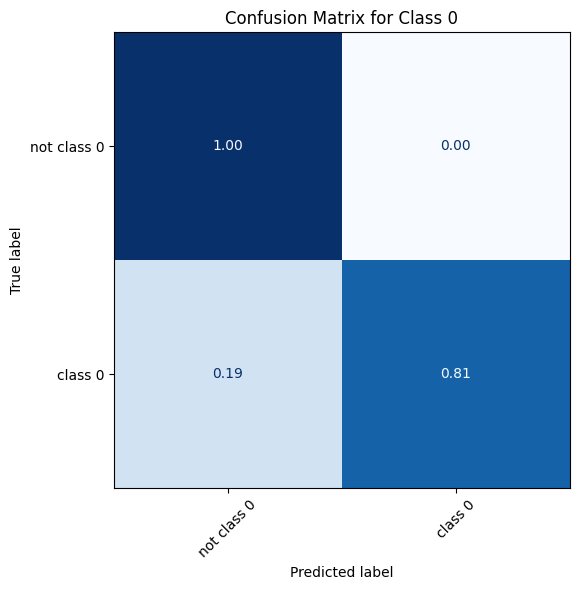

array([[9.99078341e-01, 9.21658986e-04],
       [1.93548387e-01, 8.06451613e-01]])

In [ ]:
class_id = 0

rbf_y_true = rbf_SVC.get_binary_labels(y_val, class_id)
rbf_y_pred = rbf_SVC.get_y_pred(X_val, class_id)

rbf_SVC.print_classification_report(rbf_y_true, rbf_y_pred, class_id=class_id, digits=4)
rbf_SVC.display_confusion_matrix(rbf_y_true, rbf_y_pred, class_id=class_id)

In [ ]:
now = time.time()
for class_id in range(20):
    idx_dict, _, _ = rbf_SVC.summarize_margin_samples(X_train, y_train, class_id)

    print(f"Class: {class_id} Support Vector Analysis:")
    print("     Support vectors:", len(idx_dict['support']))
    print("     Misclassified:", len(idx_dict['misclassified']))
    print("     On boundary:", len(idx_dict['on_boundary']))
    print("     Inside margin:", len(idx_dict['inside_margin']))
    print("     On margin:", len(idx_dict['on_margin']))

print(f"Time elapsed: {time.time() - now:.2f} seconds", )


Class: 0 Support Vector Analysis:
     Support vectors: 1456
     Misclassified: 1
     On boundary: 0
     Inside margin: 14
     On margin: 1453
Class: 1 Support Vector Analysis:
     Support vectors: 2215
     Misclassified: 3
     On boundary: 0
     Inside margin: 5
     On margin: 2216
Class: 2 Support Vector Analysis:
     Support vectors: 1840
     Misclassified: 2
     On boundary: 0
     Inside margin: 5
     On margin: 1846
Class: 3 Support Vector Analysis:
     Support vectors: 2253
     Misclassified: 0
     On boundary: 0
     Inside margin: 9
     On margin: 2255
Class: 4 Support Vector Analysis:
     Support vectors: 2065
     Misclassified: 0
     On boundary: 0
     Inside margin: 2
     On margin: 2080
Class: 5 Support Vector Analysis:
     Support vectors: 1959
     Misclassified: 0
     On boundary: 0
     Inside margin: 3
     On margin: 1966
Class: 6 Support Vector Analysis:
     Support vectors: 1672
     Misclassified: 3
     On boundary: 0
     Inside margin: 

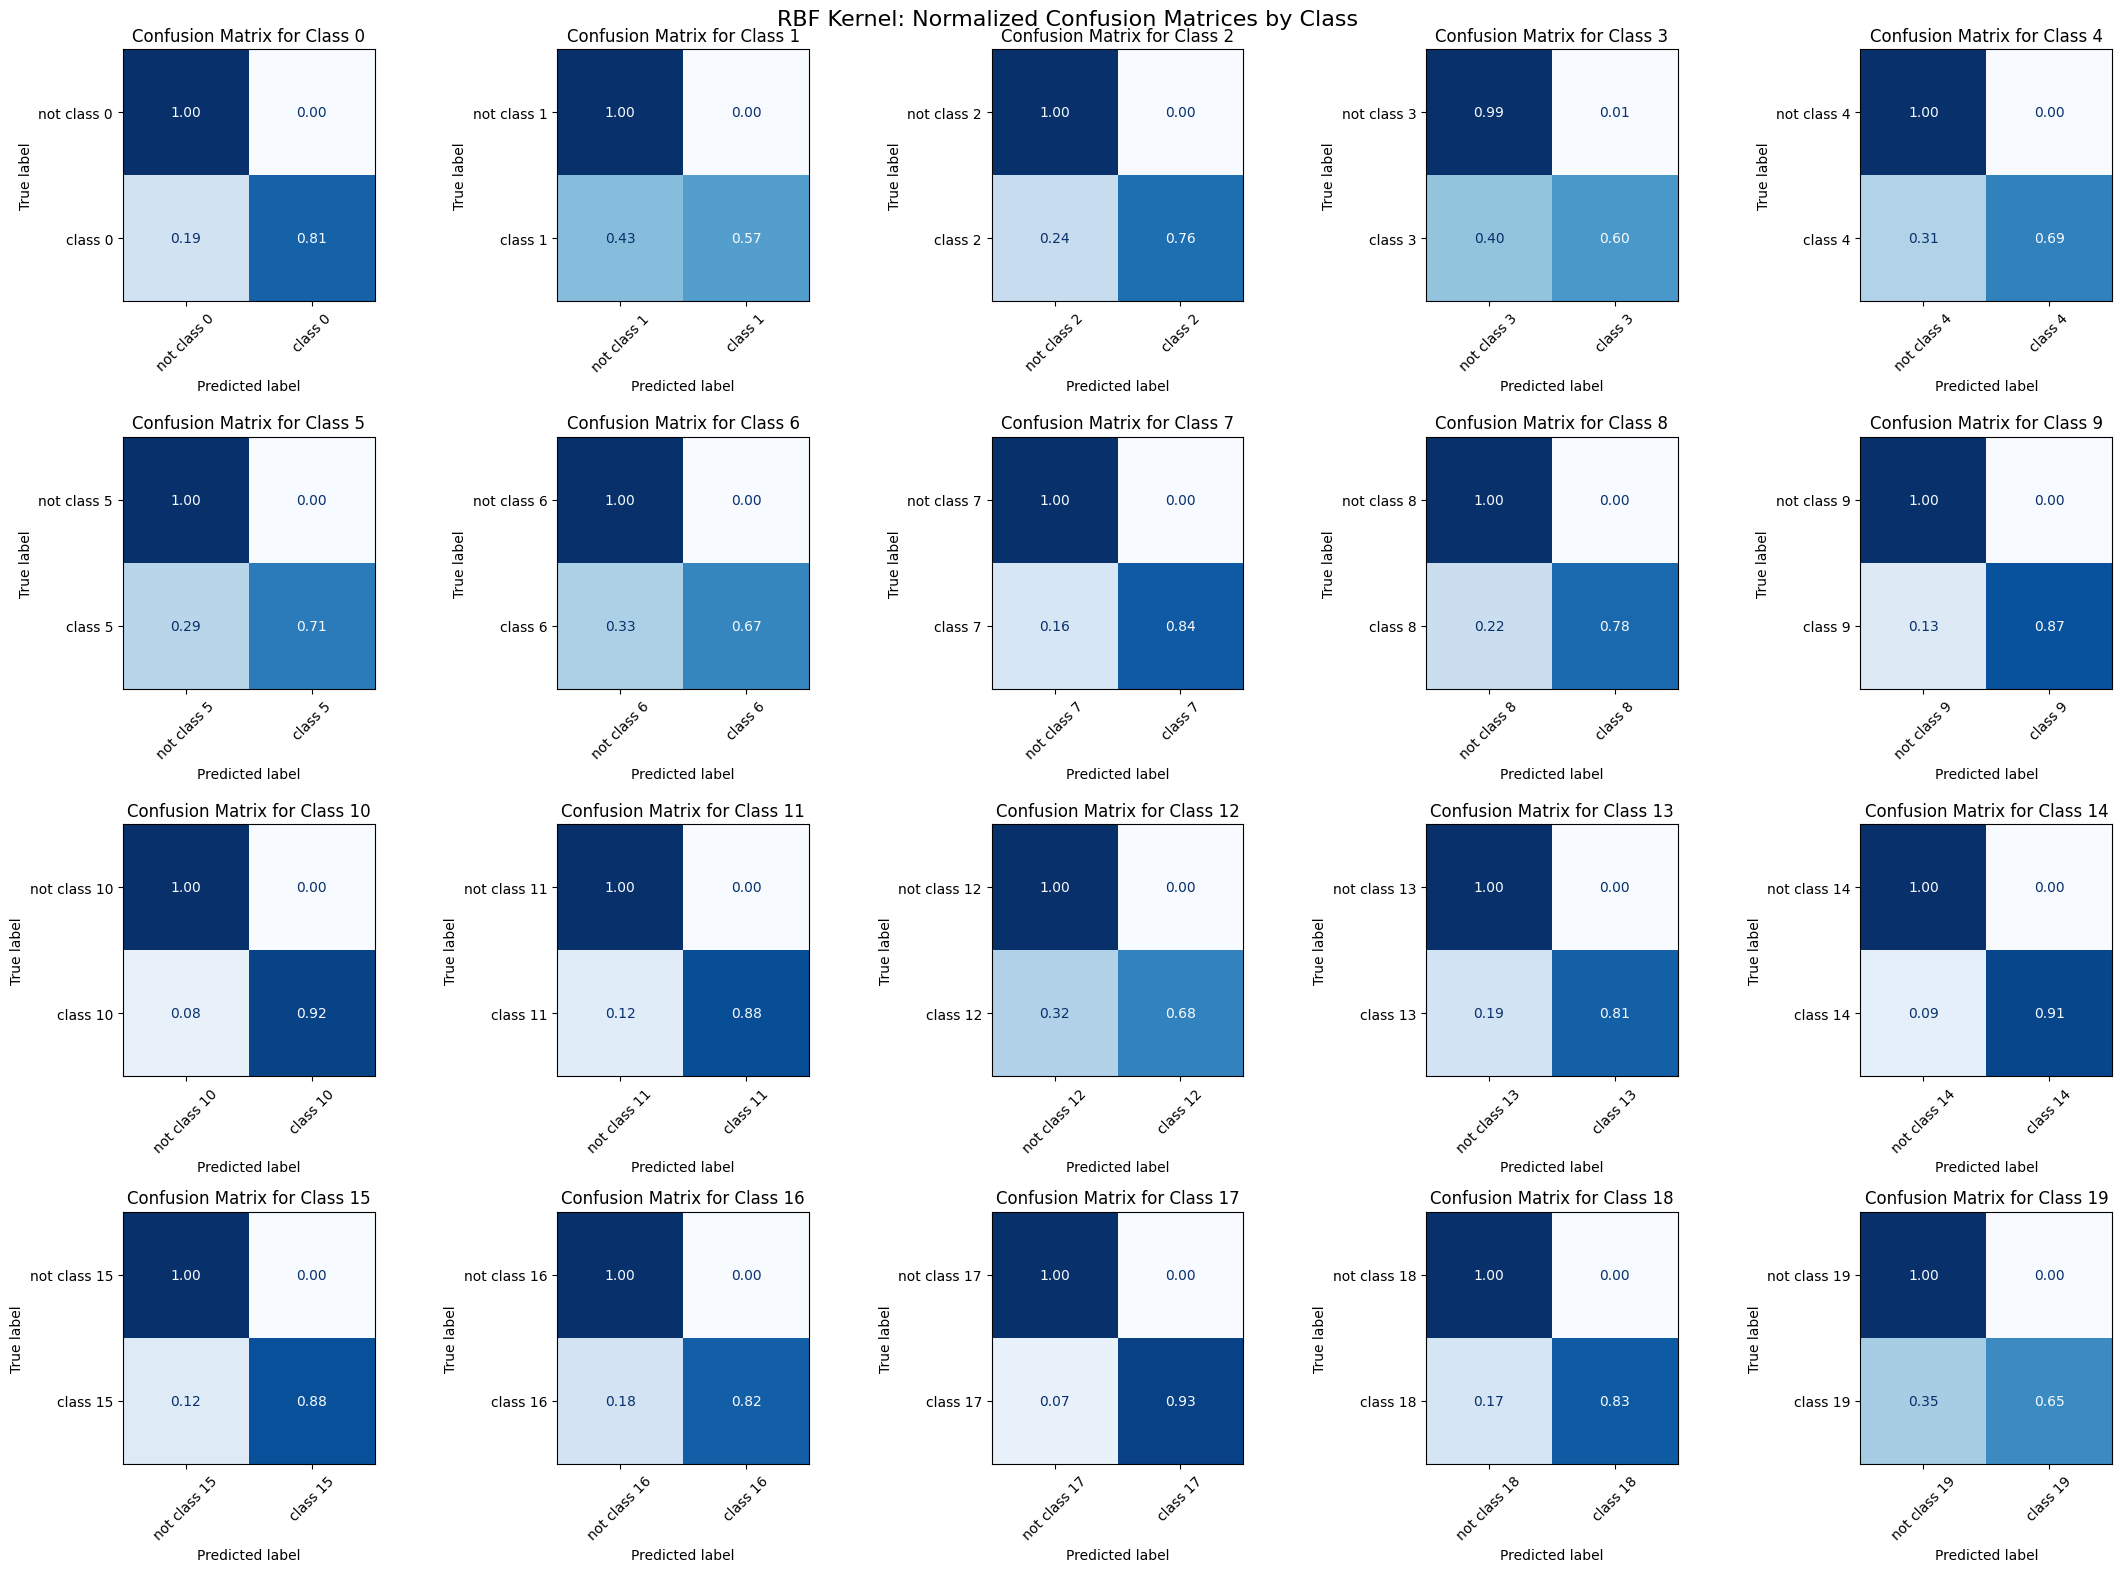

In [ ]:
svc_model = rbf_SVC
kernel_name = 'RBF'

all_confusion_matrices = {}
fig, axes = plt.subplots(4, 5, figsize=(22, 16))

for class_id, ax in zip(range(20), axes.flat):
    y_true = svc_model.get_binary_labels(y_val, class_id)
    y_pred = svc_model.get_y_pred(X_val, class_id)
    c_matrix = svc_model.display_confusion_matrix(
        y_true,
        y_pred,
        class_id=class_id,
        normalize='true',
        ax=ax,
        show=False
    )
    all_confusion_matrices[class_id] = c_matrix

fig.suptitle(f'{kernel_name} Kernel: Normalized Confusion Matrices by Class', fontsize=16)
plt.tight_layout()
plt.show()

### Matern Kernel

In [ ]:
from scipy.sparse import issparse

# Wrapper for Matern kernel to handle sparse inputs and ensure 2D output
class MaternKernelWrapper:
  def __init__(self, kernel_object=None): # Modified to accept kernel_object as keyword argument
    self.kernel_object = kernel_object

  def __call__(self, X, Y=None):
    # Convert sparse inputs to dense numpy arrays and ensure they are 2D
    X_dense = X.toarray() if issparse(X) else np.asarray(X)
    if X_dense.ndim == 1:
      X_dense = X_dense.reshape(1, -1)

    Y_dense = None
    if Y is not None:
      Y_dense = Y.toarray() if issparse(Y) else np.asarray(Y)
      if Y_dense.ndim == 1:
        Y_dense = Y_dense.reshape(1, -1)

    return self.kernel_object(X_dense, Y_dense)

  # Required for GridSearchCV if 'kernel' is a parameter to be searched over
  # Although not strictly used in this specific param_grid, good practice for custom kernels
  def get_params(self, deep=True):
    # Ensure that if deep=True, a clonable version of the internal kernel is returned
    if deep and hasattr(self.kernel_object, 'clone_with_theta'):
      return {'kernel_object': self.kernel_object.clone_with_theta(self.kernel_object.theta)}
    else:
      return {'kernel_object': self.kernel_object}

  def set_params(self, **parameters):
    if 'kernel_object' in parameters:
      self.kernel_object = parameters['kernel_object']
    return self

matern_params = [
    (0.5, 1.0),
    (0.5, 1.5),
    (0.5, 2.5),
    (1.0, 1.0),
    (1.0, 1.5),
    (1.0, 2.5),
    (1.5, 2.5)
]

matern_kernels = [
    MaternKernelWrapper(Matern(length_scale=p[0], nu=p[1])) for p in matern_params
]

matern_params = {
    'kernel': matern_kernels,
    'C': [0.5, 1, 10]
}

now = time.time()
matern_SVC = OVR_SVC(20, matern_params, strat_cv)
matern_SVC.fit(X_train, y_train, range(1))
matern_SVC.validate(X_val, y_val, range(1))
print("Time Elapsed: ", time.ctime(time.time() - now))

ValueError: 
All the 105 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\svm\_base.py", line 266, in fit
    fit(X, y, sample_weight, solver_type, kernel, random_seed=seed)
  File "c:\Users\chris\Documents\G

---
---
# Problem 4:
## Credit Risk Prediction with Support Vector Machines

In this problem we build a credit risk prediction model using Support Vector Machines (SVMs) with kernel methods.

The dataset contains information about borrowers and their financial characteristics. The goal is to train a classifier that can correctly predict whether a borrower represents high or low credit risk.

Unlike many real-world datasets, this dataset has no missing values and minimal preprocessing requirements, allowing us to focus on the use of kernel-based classifiers.

We will begin with a base SVM classifier, selecting an appropriate kernel and analyzing the behavior of the model.

---

## Tasks

1. Split the dataset into **training, validation, and test sets**, ensuring that the test data is never used during training or model selection.

2. Train a Support Vector Classifier and examine:
   - **Support vectors**
   - **Dual coefficients**
   - **The effect of kernel hyperparameters on model performance.**

3. Investigate methods for allowing different margins for positive and negative classes, and explain why this approach may be useful in a credit risk setting.

4. Explore how to generate probability estimates for class labels and explain why this approach is reasonable.

5. Extend the base model using ensemble methods, such as:
   - **Bagging**
   - **Boosting**

---


In [ ]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from contextlib import redirect_stdout
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)

# data (as pandas dataframes)
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

# metadata
print(default_of_credit_card_clients.metadata)

# variable information
print(default_of_credit_card_clients.variables)




{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

In [ ]:
# For Problm 1 and 2
# Parameter Tunning,
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
def main():

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(class_weight='balanced'))  # class_weight='balanced' to handle class imbalance
    ])


    # -------define model with different Kernel----------
    param_grid = {
        'clf__C': [0.1, 1, 10]
    }

    kernels = {
        "linear": {"clf__kernel": ["linear"]},
        "rbf": {"clf__kernel": ["rbf"], "clf__gamma": ["scale", "auto"]},
        "poly": {"clf__kernel": ["poly"], "clf__degree": [2,3]}
    }

    # train model withs with GridSearchCV
    all_results = []
    best_grid = None
    best_cv_score = float("-inf")
    for kernel, params in kernels.items():

        parameters = {**param_grid, **params}

        grid = GridSearchCV(
            pipeline,
            parameters,
            cv=3,
            n_jobs=-1,
            return_train_score=True,
            verbose=1
        )

        grid.fit(X_train, y_train)
        if grid.best_score_ > best_cv_score:
            best_cv_score = grid.best_score_
            best_grid = grid

        # iterate through every parameter combination and print results
        for i in range(len(grid.cv_results_['params'])):
            params_i = grid.cv_results_['params'][i]
            all_results.append({
                "Kernel": params_i.get('clf__kernel'),
                "C": params_i.get('clf__C'),
                "Gamma": params_i.get('clf__gamma', None),
                "Degree": params_i.get('clf__degree', None),
                "Mean CV Score": grid.cv_results_['mean_test_score'][i],
                "Std CV Score": grid.cv_results_['std_test_score'][i],
                "Train Score": grid.cv_results_['mean_train_score'][i],
                "Total Support Vectors": grid.best_estimator_.named_steps['clf'].support_vectors_.shape[0]  # only best model
            })


    # convert to dataframe
    results_df = pd.DataFrame(all_results)
    results_df = results_df.sort_values(by="Mean CV Score", ascending=False)
    print("\nAll Parameter Performance:")
    print(results_df)

    best_model = best_grid.best_estimator_
    # find best kernel from the highest-scoring row
    best_kernel = results_df.iloc[0]["Kernel"]
    print("\nBest kernel:", best_kernel)
    dual_coeff = best_model.named_steps['clf'].dual_coef_
    print(dual_coeff)
    print("\nDual coefficients shape:", dual_coeff.shape)  # shape of dual coefficients
    # in binary classification, dual_coef_ shape = (1, n_support_vectors)

    # evaluate model on the test data
    y_pred = best_model.predict(X_test)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))

    # --- Inspect support vectors and dual coefficients of best model ---
    svm_model = best_model.named_steps['clf']
    print("\nNumber of support vectors per class:", svm_model.n_support_)
    print("Total support vectors:", svm_model.support_vectors_.shape[0])
    print("Dual coefficients shape:", svm_model.dual_coef_.shape)
    print("Dual coefficients (first 10 values):", svm_model.dual_coef_[0][:10])


if __name__ == "__main__":
    with open("output.txt", "w", encoding="utf-8") as f:
        with redirect_stdout(f):
            main()


c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


To Explore how to generate probability estimates for class labels and explain why this approach is reasonable.
We set the SVC(probability=True).
Just replace code here with previous one and running the code below, save the result   =output file name "SVC_prob"

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(class_weight='balanced', **probability=True**))  # class_weight='balanced' to handle class imbalance
    ])



We use the Ensemble methods Bagging and Boosting to improve prediction performance, reduce variance.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Baseline Model and Hyperparameter Tuning
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(class_weight='balanced'))
])

param_grid = {
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 'auto'],
    'svc__degree': [2, 3]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest SVM parameters:")
print(grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_svm = grid.best_estimator_


# ----- Bagging with SVM -----

bagging_model = BaggingClassifier(
    estimator=SVC(
        kernel=grid.best_params_['svc__kernel'],
        C=grid.best_params_['svc__C'],
        gamma=grid.best_params_.get('svc__gamma', 'scale')
    ),
    n_estimators=10,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(X_train, y_train)

# ----- Boosting with SVM

boosting_model = AdaBoostClassifier(
    estimator=SVC(
        kernel=grid.best_params_['svc__kernel'],
        C=grid.best_params_['svc__C'],
        gamma=grid.best_params_.get('svc__gamma', 'scale')),

    n_estimators=20,
    learning_rate=0.5,
    random_state=42
)

boosting_model.fit(X_train, y_train)


#------Evaluate Models on Test Data

models = {
    "Best SVM": best_svm,
    "Bagging SVM": bagging_model,
    "Boosting SVM": boosting_model
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("\n==========================")
    print(name)
    print("==========================")

    print("Accuracy:", acc)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": acc
    })

# Model comparation
results_df = pd.DataFrame(results)

print("\nModel Comparison:")
print(results_df.sort_values(by="Accuracy", ascending=False))

Fitting 3 folds for each of 36 candidates, totalling 108 fits


c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Best SVM parameters:
{'svc__C': 0.1, 'svc__degree': 3, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}
Best CV Score: 0.797875


c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\ensemble\_bagging.py:988: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Best SVM
Accuracy: 0.7978333333333333

Confusion Matrix:
[[4163  524]
 [ 689  624]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      4687
           1       0.54      0.48      0.51      1313

    accuracy                           0.80      6000
   macro avg       0.70      0.68      0.69      6000
weighted avg       0.79      0.80      0.79      6000


Bagging SVM
Accuracy: 0.7811666666666667

Confusion Matrix:
[[4687    0]
 [1313    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4687
           1       0.00      0.00      0.00      1313

    accuracy                           0.78      6000
   macro avg       0.39      0.50      0.44      6000
weighted avg       0.61      0.78      0.69      6000



c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(


Boosting SVM
Accuracy: 0.7811666666666667

Confusion Matrix:
[[4687    0]
 [1313    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4687
           1       0.00      0.00      0.00      1313

    accuracy                           0.78      6000
   macro avg       0.39      0.50      0.44      6000
weighted avg       0.61      0.78      0.69      6000


Model Comparison:
          Model  Accuracy
0      Best SVM  0.797833
1   Bagging SVM  0.781167
2  Boosting SVM  0.781167


c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\Documents\GitHub\kernel_methods_hw\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(